###### Piotr Stachowicz 337942

# Assignment 2

### Task 0

In [1]:
import os
from pathlib import Path
import time

import wandb
import matplotlib.pyplot as plt
from torchvision.models import vgg13
import numpy as np
from tqdm import tqdm
from PIL import Image
from scipy.io import loadmat
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

DATA_PATH = './data'
IMAGE_PATH = os.path.join(DATA_PATH, 'images')
MODELS_PATH = './models'
torch.manual_seed(42)
device = torch.device('cuda')

In [2]:
flower_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

data = loadmat(os.path.join(DATA_PATH, 'imagelabels.mat'))
flower_labels = torch.tensor(data['labels'], dtype=torch.long).squeeze() - 1 # (8189,)
setid = loadmat(os.path.join(DATA_PATH, 'setid.mat'))

train_idx = setid['trnid'].squeeze() - 1
val_idx   = setid['valid'].squeeze() - 1
test_idx  = setid['tstid'].squeeze() - 1

In [3]:
class FlowerDataset(Dataset):
    def __init__(self, transform, labels, indices):
        all_files = sorted(os.listdir(IMAGE_PATH))
        self.files = [all_files[i] for i in indices]
        self.transform = transform
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = Image.open(os.path.join(IMAGE_PATH, self.files[idx])).convert('RGB')
        image = self.transform(file)
        label = self.labels[idx]

        return image, label

In [4]:
class ExampleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(ExampleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        self.c = 56*56*16
        self.fc1 = nn.Linear(self.c, 1024) # Flatten (512 * 7 * 7) features
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, self.c) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # logits for all classes
        
        return x
    

def train_model(model, criterion, train_loader, test_loader, val_loader, optimizer, epochs, patience, min_delta, name, val_accuracies=None, epoch_times=None):
    wandb.init(
        project='ADM',
        name=name,
        reinit=True
    )

    model.to(device)
    model.train()

    current_patience = 0
    best_val_loss = float('inf')
    last_loss = None

    for epoch in tqdm(range(epochs)):
        start_time = time.time()
        model.train()
        wdb_loss = {}
        t_loss = 0.0
        
        for X, y_true in train_loader:
            X = X.to(device)
            y_true = y_true.to(device)

            optimizer.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y_true)

            loss.backward()
            optimizer.step()

            t_loss += loss.item() * X.size(0)
        
        epoch_train_loss = t_loss / len(train_loader.dataset)
        wdb_loss['epoch-train-loss'] = epoch_train_loss

        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for X, y_true in val_loader:
                X = X.to(device)
                y_true = y_true.to(device)

                y_pred = model(X)
                loss = criterion(y_pred, y_true)
                
                val_loss += loss.item() * X.size(0)

                preds = torch.argmax(y_pred, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_true.cpu().numpy())
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
        wdb_loss['epoch-val-loss'] = epoch_val_loss

        wandb.log(wdb_loss)
        
        if val_accuracies is not None:
            epoch_val_acc = accuracy_score(all_targets, all_preds)
            val_accuracies.append(epoch_val_acc)

        # ---- EARLY STOPPING ----
        if epoch_val_loss < best_val_loss and (last_loss is None or abs(last_loss - epoch_val_loss) >= min_delta):
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), os.path.join(DATA_PATH, f'{name}.pth'))
            current_patience = 0
        else:
            current_patience += 1
        
        if epoch_times is not None:
            epoch_duration = time.time() - start_time
            epoch_times.append(epoch_duration)

        if current_patience >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
        
        last_loss = epoch_val_loss

In [5]:
train_dataset = FlowerDataset(flower_transform, flower_labels, train_idx)
test_dataset = FlowerDataset(flower_transform, flower_labels, test_idx)
val_dataset = FlowerDataset(flower_transform, flower_labels, val_idx)

### CNN

In [ ]:
cnn_model: nn.Module = ExampleCNN()

train_model(
    model = cnn_model,
    criterion = nn.CrossEntropyLoss(),
    train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True),
    test_loader = DataLoader(dataset=test_dataset, batch_size=256, shuffle=True),
    val_loader = DataLoader(dataset=val_dataset, batch_size=256, shuffle=True),
    optimizer = optim.Adam(cnn_model.parameters(), lr=0.001),
    epochs = 1024,
    patience = 5,
    min_delta=0.0,
    name = 'CNN'
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/piotrs/.netrc.
wandb: Currently logged in as: 337942 (337942-university-of-wroclaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  2%|▏         | 18/1024 [01:22<1:17:01,  4.59s/it]

Early stopping triggered at epoch 19


The model trained well. It was minimalizing both train and validation losses consitently. With early stopping, the training took 3 minutes.



### Small CNN with 10% of the training set

In [7]:
small_train_idx = np.random.choice(train_idx, int(len(train_idx) * 0.1), replace=False)
small_train_dataset = FlowerDataset(flower_transform, flower_labels, small_train_idx)

In [ ]:
small_cnn_model: nn.Module = ExampleCNN()

train_model(
    model=small_cnn_model,
    criterion = nn.CrossEntropyLoss(),
    train_loader = DataLoader(dataset=small_train_dataset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True),
    test_loader = DataLoader(dataset=test_dataset, batch_size=256, shuffle=True),
    val_loader = DataLoader(dataset=val_dataset, batch_size=256, shuffle=True),
    optimizer = optim.Adam(small_cnn_model.parameters(), lr=0.001),
    epochs = 1024,
    patience = 5,
    min_delta=0.0,
    name = 'smallCNN'
)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch-train-loss,█▆▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
epoch-val-loss,█▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-train-loss,0.99721
epoch-val-loss,1.7499


  0%|          | 5/1024 [00:19<1:06:24,  3.91s/it]

Early stopping triggered at epoch 6


The smaller CNN overfitted to the training set and the validation loss skyrockets.

### VGG-13

In [ ]:
vgg13_model = vgg13(pretrained=False)
vgg13_model.classifier[6] = nn.Linear(4096, 102)

train_model(
    model=vgg13_model,
    criterion = nn.CrossEntropyLoss(),
    train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True),
    test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=True),
    val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=True),
    optimizer = optim.Adam(vgg13_model.parameters(), lr=1e-5),
    epochs = 1024,
    patience = 5,
    min_delta=0.0,
    name = 'vgg13'
)

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/piotrs/.netrc.
wandb: Currently logged in as: 337942 (337942-university-of-wroclaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  4%|▎         | 37/1024 [10:57<4:52:11, 17.76s/it]

Early stopping triggered at epoch 38


The VGG13 model did great job, it has about 133mln parameters so I had to decrease the lr to 1e-5. The train loss graph has steady drop, whlist the validation loss was also very low. It did beat the ExampleCNN model (by a bit).

Dataset used in the paper to train the original VGG13: ImageNet Large‑Scale Visual Recognition Challenge
~1.2 million training images
~50,000 validation images
~150,000 test images
~1000 object categories
4 NVIDIA GPUs 2–3 weeks


I guess the conclusions are:
- since the dataset is very small the small_cnn overfitted,
- the ExampleCNN did almost as great of a job as VGG13 did, we might transfer learning in this situation.

### Task 1

In [5]:
full_vgg13 = vgg13(pretrained=True)
full_vgg13.classifier[6] = nn.Linear(4096, 102)

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
# Reinitialize
nn.init.kaiming_uniform_(full_vgg13.classifier[6].weight, a=0, mode='fan_in', nonlinearity='relu')
nn.init.zeros_(full_vgg13.classifier[6].bias)

# Freeze
for param in full_vgg13.features.parameters():
    param.requires_grad = False

In [ ]:
accuracies = []
train_model(
    model=full_vgg13,
    criterion = nn.CrossEntropyLoss(),
    train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True),
    test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=True),
    val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=True),
    optimizer = optim.Adam(full_vgg13.parameters(), lr=1e-5),
    epochs = 1024,
    patience = 3,
    min_delta=0.0,
    name = 'full_vgg13',
    val_accuracies=accuracies
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/piotrs/.netrc.
wandb: Currently logged in as: 337942 (337942-university-of-wroclaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  3%|▎         | 29/1024 [05:45<3:17:18, 11.90s/it]

Early stopping triggered at epoch 30


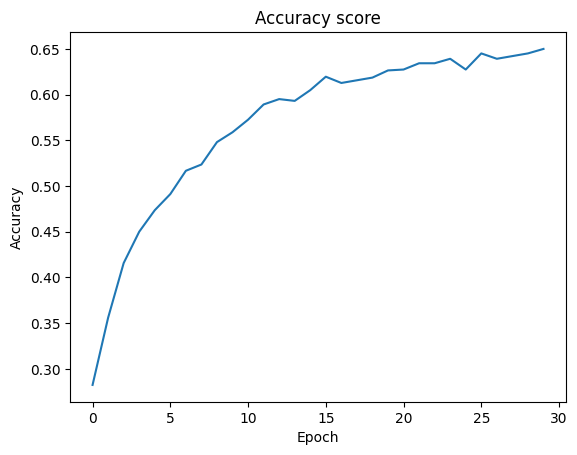

In [11]:
plt.figure()
plt.title('Accuracy score')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(accuracies)
plt.show()

### Experiment with freezing first i layers

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/piotrs/.netrc.
wandb: Currently logged in as: 337942 (337942-university-of-wroclaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_

 13%|█▎        | 134/1024 [23:18<2:34:47, 10.43s/it]

Early stopping triggered at epoch 135


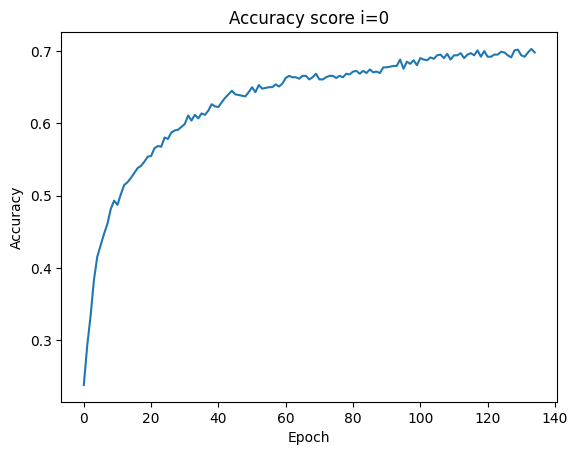

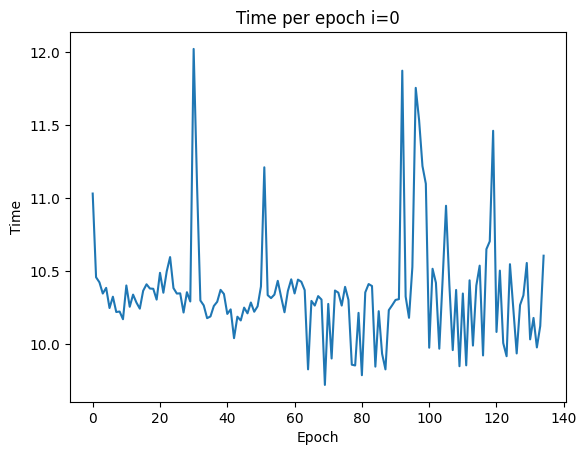

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch-train-loss,█▆▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-val-loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-train-loss,0.15946
epoch-val-loss,0.8639


 11%|█▏        | 116/1024 [20:50<2:43:10, 10.78s/it]

Early stopping triggered at epoch 117


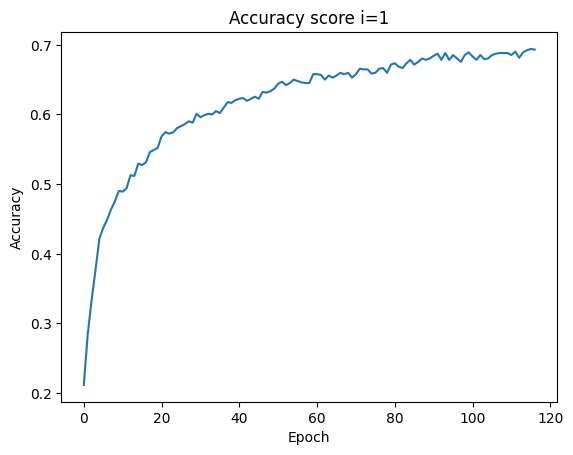

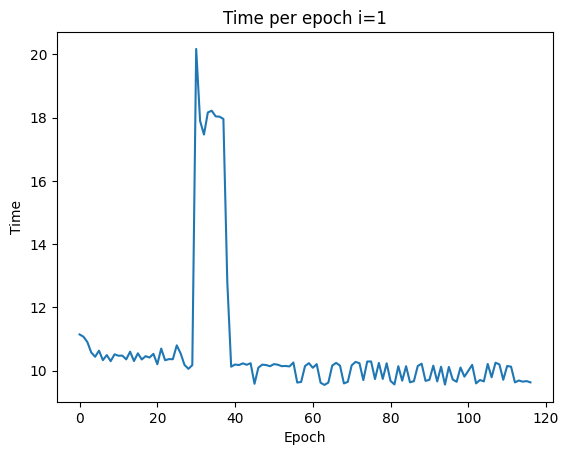

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


epoch-train-loss,█▇▆▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-val-loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-train-loss,0.19171
epoch-val-loss,0.8726


 22%|██▏       | 225/1024 [37:35<2:13:28, 10.02s/it]

Early stopping triggered at epoch 226


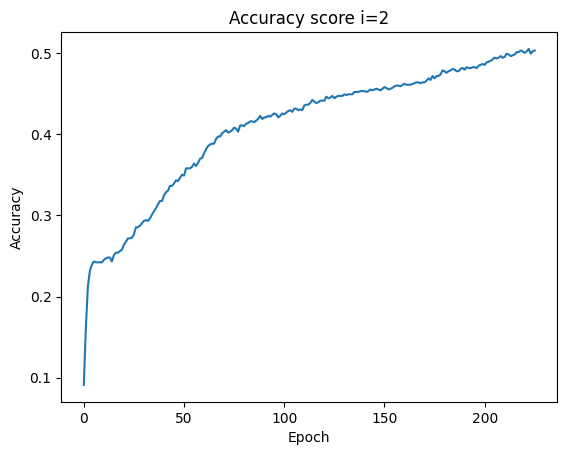

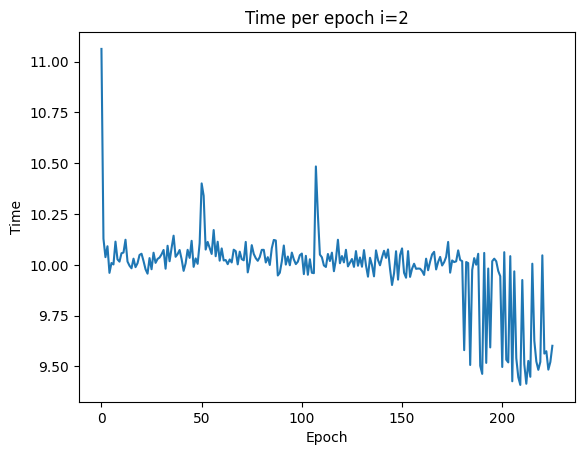

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch-train-loss,█▇▆▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-val-loss,█▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-train-loss,1.31019
epoch-val-loss,1.27864


 19%|█▉        | 195/1024 [1:49:17<7:44:39, 33.63s/it]    

Early stopping triggered at epoch 196


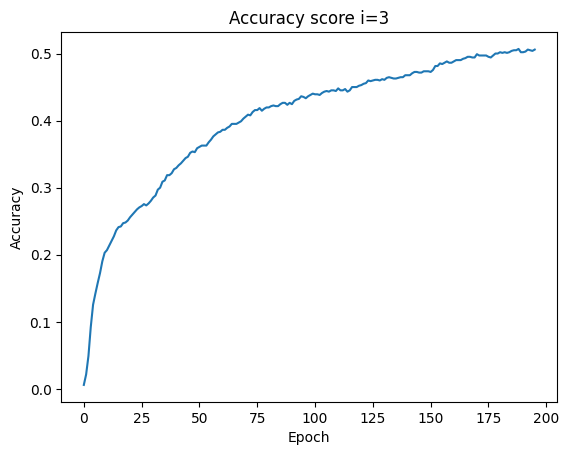

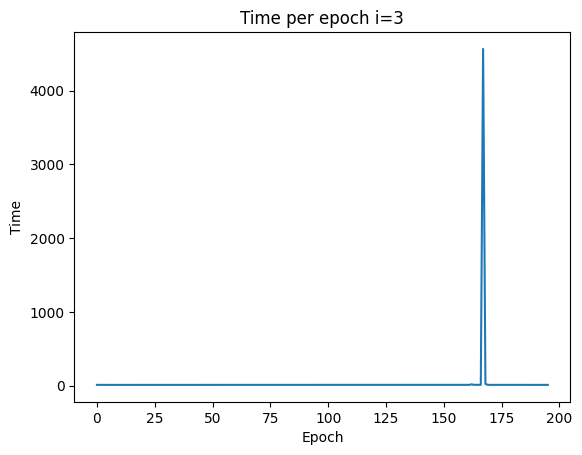

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


epoch-train-loss,█▆▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-val-loss,█▇▆▄▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch-train-loss,1.39448
epoch-val-loss,1.29675


  0%|          | 5/1024 [01:01<3:29:19, 12.33s/it]

Early stopping triggered at epoch 6


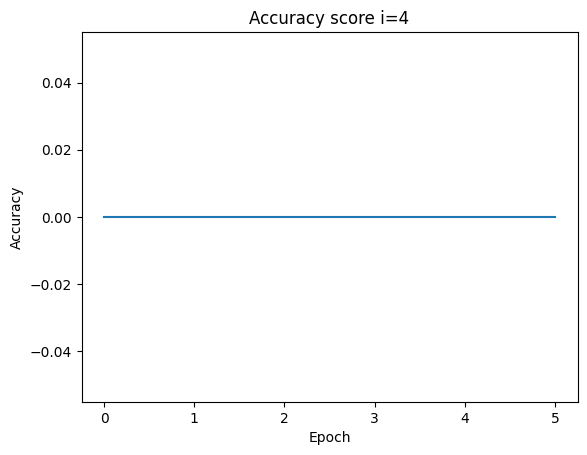

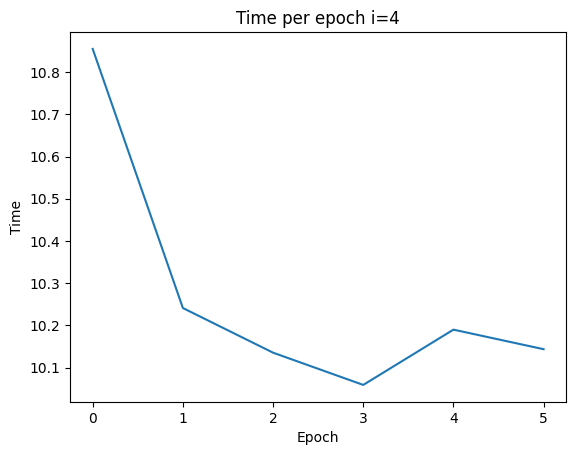

/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/piotrs/masters/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch-train-loss,▄█▁▂▇▅
epoch-val-loss,█▇▅▄▂▁
epoch-train-loss,5.1401
epoch-val-loss,4.77521


  0%|          | 0/1024 [00:00<?, ?it/s]


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [6]:
for i in range(0, 7):
    full_vgg13 = vgg13(pretrained=True)
    full_vgg13.classifier[6] = nn.Linear(4096, 102)

    # Reinitialize
    nn.init.kaiming_uniform_(full_vgg13.classifier[6].weight, a=0, mode='fan_in', nonlinearity='relu')
    nn.init.zeros_(full_vgg13.classifier[6].bias)

    # Freeze the conv layers
    for param in full_vgg13.features.parameters():        
        param.requires_grad = False

    # Freeze layers [0..i]
    for x, param in enumerate(full_vgg13.classifier.parameters()):
        if x > i:
            break

        param.requires_grad = False
    
    accuracies = []
    time_per_epoch = []
    train_model(
        model=full_vgg13,
        criterion = nn.CrossEntropyLoss(),
        train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True),
        test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=True),
        val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=True),
        optimizer = optim.Adam(full_vgg13.parameters(), lr=1e-5),
        epochs = 1024,
        patience = 5,
        min_delta = 1e-3,
        name = f'exp_full_vg13({i})',
        val_accuracies=accuracies,
        epoch_times=time_per_epoch
    )

    plt.figure()
    plt.title(f'Accuracy score i={i}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.plot(accuracies)
    plt.show()

    plt.figure()
    plt.title(f'Time per epoch i={i}')
    plt.xlabel('Epoch')
    plt.ylabel('Time')
    plt.plot(time_per_epoch)
    plt.show()

### Task 3

In [2]:
from torchvision import datasets, transforms

transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform_base
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform_base
)

train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True)

def augment(x):
    transform = transforms.Compose([
        transforms.RandomResizedCrop(size=28, scale=(0.6, 1.0)),
        transforms.RandomRotation(15),
    ])

    return transform(x), transform(x)

In [3]:
class ConvNet(nn.Module):
    def __init__(self, hidden_dim=128, feature_dim=64):
        super(ConvNet, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), # 8x28x28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 8x14x14
            nn.Conv2d(8, 16, kernel_size=3, padding=1), # 16x14x14
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 16x7x7
            nn.Flatten()
        )

        self.c = 16 * 7 * 7
        self.projector = nn.Linear(in_features=self.c, out_features=hidden_dim)

        self.downstream = nn.Sequential(
            nn.Linear(in_features=hidden_dim, out_features=hidden_dim),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim, out_features=feature_dim)
        )

    def forward(self, x, supervision=False):
        x = self.encoder(x)
        embedding = F.relu(self.projector(x))

        if not supervision:
            return embedding

        feature = self.downstream(embedding)

        return feature

##### Un-supervised learning

In [4]:
def contrastive_loss(zi, zj, temperature=0.1):
    batch_size = zi.shape[0]
    
    zi = F.normalize(zi, dim=1)
    zj = F.normalize(zj, dim=1)
    
    representations = torch.cat([zi, zj], dim=0)
    
    similarity_matrix = torch.matmul(representations, representations.T)
    
    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)
    
    positives = torch.cat([sim_ij, sim_ji], dim=0)

    mask = ~torch.eye(2 * batch_size, device=zi.device).bool()
    negatives = similarity_matrix[mask].view(2 * batch_size, -1)

    logits = torch.cat([positives.unsqueeze(1), negatives], dim=1)
    logits /= temperature

    labels = torch.zeros(2 * batch_size, device=zi.device, dtype=torch.long)
    
    return F.cross_entropy(logits, labels)

In [5]:
model = ConvNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 15

for epoch in range(EPOCHS):
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for x, _ in pbar:
        x = x.to(device)
        xi, xj = augment(x)
        
        zi = model(xi, supervision=False)
        zj = model(xj, supervision=False)

        loss = contrastive_loss(zi, zj)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    print(f"Average Epoch Loss: {total_loss / len(train_loader):.4f}")

Epoch 1/15: 100%|██████████| 235/235 [00:07<00:00, 29.90it/s, loss=1.97]


Average Epoch Loss: 3.5992


Epoch 2/15: 100%|██████████| 235/235 [00:07<00:00, 30.10it/s, loss=1.55]


Average Epoch Loss: 2.6058


Epoch 3/15: 100%|██████████| 235/235 [00:09<00:00, 24.88it/s, loss=1.39]


...

Average Epoch Loss: 1.8375


Epoch 14/15: 100%|██████████| 235/235 [00:10<00:00, 22.18it/s, loss=1.14]


Average Epoch Loss: 1.8107


Epoch 15/15: 100%|██████████| 235/235 [00:09<00:00, 25.00it/s, loss=1.11]

Average Epoch Loss: 1.8126


##### Supervised learning

In [8]:
def get_few_shot_dataset(dataset, n_samples_per_digit=50):
    indices = []

    for digit in range(10):
        digit_indices = np.where(dataset.targets == digit)[0]

        selected_indices = np.random.choice(digit_indices, n_samples_per_digit, replace=False)
        indices.extend(selected_indices)
    
    return Subset(dataset, indices)

In [15]:
few_shot_dataset = get_few_shot_dataset(train_dataset, n_samples_per_digit=50)

few_shot_loader = DataLoader(few_shot_dataset, batch_size=10, shuffle=True)

In [ ]:
model.eval()
train_features = []
train_labels = []

with torch.no_grad():
    for x, y in few_shot_loader:
        x = x.to(device)

        h = model(x, supervision=False) 

        h = F.normalize(h, dim=1)
        
        train_features.append(h.cpu().numpy())
        train_labels.append(y.numpy())

X_train_knn = np.concatenate(train_features, axis=0)
y_train_knn = np.concatenate(train_labels, axis=0)

knn = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn.fit(X_train_knn, y_train_knn)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
test_features = []
test_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        
        h = model(x, supervision=False)
        
        h = F.normalize(h, dim=1)
        
        test_features.append(h.cpu().numpy())
        test_labels.append(y.numpy())

X_test = np.concatenate(test_features, axis=0)
y_test = np.concatenate(test_labels, axis=0)

y_pred = knn.predict(X_test)

accuracy = (y_pred == y_test).mean()
print(f"Poprawiona celność (supervision=False + L2): {accuracy * 100:.2f}%")

Poprawiona celność (supervision=False + L2): 88.90%
